In [11]:
from scipy import sparse
from ase.build import molecule
from ase.neighborlist import get_connectivity_matrix
from ase.neighborlist import natural_cutoffs
from ase.neighborlist import NeighborList
import ase
import numpy as np
from ase.io import read
from ase import Atoms
import ase.visualize
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview
from ase.build import molecule
from ase.neighborlist import NeighborList
import matplotlib.pyplot as plt
from cell2mol.new_cell_reconstruction import apply_symmetry_operations_reference

In [2]:
name = "ACEYOW"
infopath = f"{name}/{name}.info"
input_path = f"{name}/{name}.cif"

In [3]:
labels, pos, ref_labels, ref_fracs, cellvec, cell_param = readinfo(infopath)

In [6]:
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_vector = atoms.cell.array
# cell_parameters = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 1 and 10 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 11 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 12 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 4 and 13 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 5 and 14 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 6 and 15 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_posit

<Axes: >

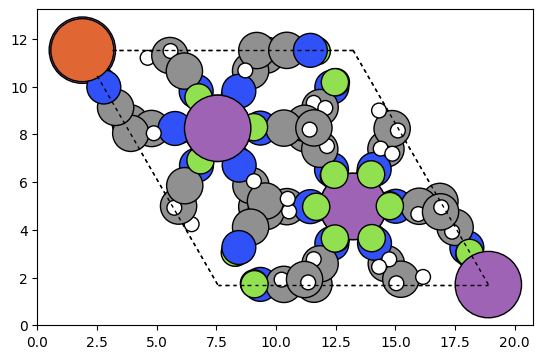

In [58]:
plot_atoms(atoms)

In [59]:
ref_molecule = Atoms(symbols=ref_labels, scaled_positions=ref_fracs, cell=cell_vector, pbc=True)

<Axes: >

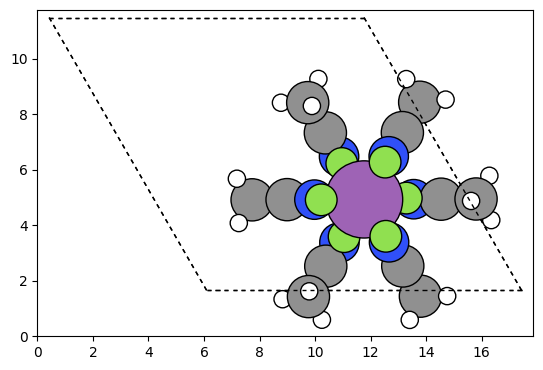

In [9]:
plot_atoms(ref_molecule)

In [60]:
new_structures = apply_symmetry_operations_reference(ref_molecule, cell_vector, sym_ops)

In [61]:
len(new_structures)

36

<Axes: >

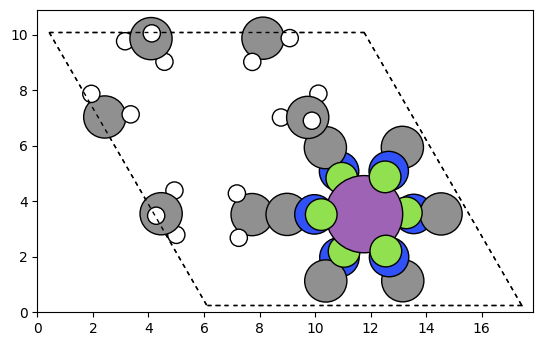

In [62]:
plot_atoms(new_structures[0])

<Axes: >

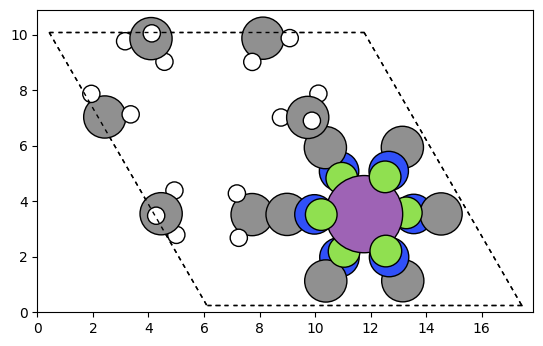

In [63]:
plot_atoms(new_structures[1])

<Axes: >

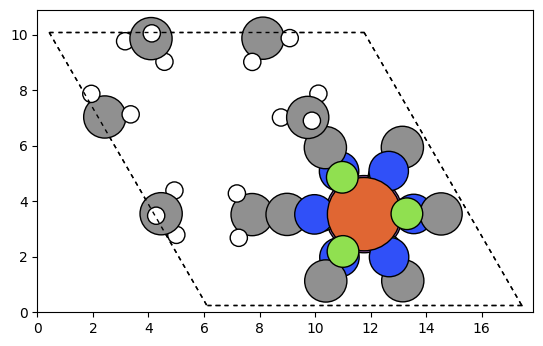

In [64]:
plot_atoms(new_structures[12])

In [21]:
for new in new_structures:
    print(len(new.numbers))

44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44


In [38]:
len([0, 3, 4, 5, 15, 16, 17, 21, 22, 23, 33, 34, 35, 39, 40, 41, 51, 52, 53, 57, 58, 59, 75, 76, 77, 93, 94, 95, 111, 117, 118, 119, 135, 136, 137])

35

In [39]:
len([0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, -1, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, 43])

35

In [45]:
indices_in_ref=[0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, -1, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, 43]

In [57]:
# Given lists
updated = [0, 3, 4, 5, 15, 16, 17, 21, 22, 23, 33, 34, 35, 39, 40, 41, 51, 52, 53, 57, 58, 59, 75, 76, 77, 93, 94, 95, 111, 117, 118, 119, 135, 136, 137]
indices_in_ref = [0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, -1, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42, -1]
print(len(updated), len(indices_in_ref))
# Find all indices of -1 in indices_in_ref
indices_to_remove = [i for i, x in enumerate(indices_in_ref) if x == -1]
indices_in_ref = [x for x in indices_in_ref if x != -1]

print(indices_to_remove)

# Remove corresponding elements from 'updated' starting from the highest index
for index in sorted(indices_to_remove, reverse=True):
    if index < len(updated):  # Check if index is valid for 'updated'
        updated.pop(index)

print(updated)
print(indices_in_ref)
print(len(updated), len(indices_in_ref))


35 35
[17, 34]
[0, 3, 4, 5, 15, 16, 17, 21, 22, 23, 33, 34, 35, 39, 40, 41, 51, 53, 57, 58, 59, 75, 76, 77, 93, 94, 95, 111, 117, 118, 119, 135, 136]
[0, 1, 10, 16, 22, 28, 34, 2, 11, 17, 23, 29, 35, 3, 12, 18, 24, 36, 4, 13, 19, 5, 14, 20, 6, 15, 21, 7, 8, 40, 41, 9, 42]
33 33


In [46]:
indices_in_ref.index(-1)

17

<Axes: >

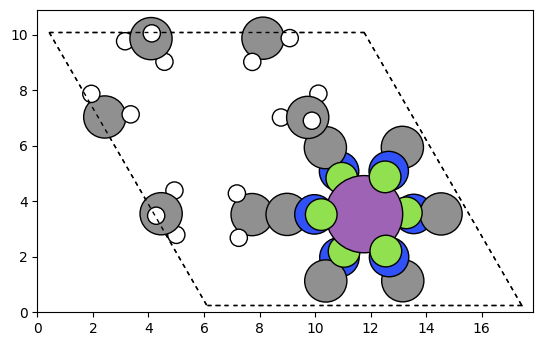

In [26]:
plot_atoms(new_structures[0])

<Axes: >

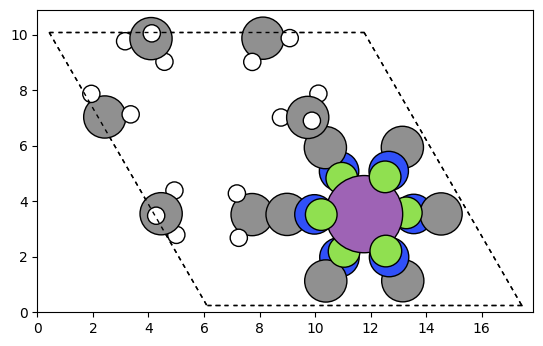

In [27]:
plot_atoms(new_structures[1])

<Axes: >

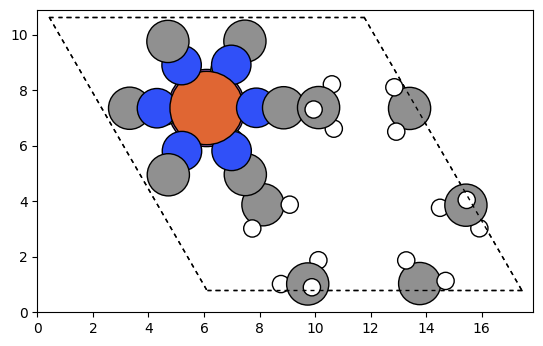

In [37]:
plot_atoms(new_structures[10])

In [9]:
from cell2mol.classes import cell
newcell = cell(name, cell_labels, cell_pos, cell_fracs, cell_vector, cell_param)
newcell.get_subtype("unit_cell")

In [10]:
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=0)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 2.0
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
 

In [11]:
for ref in newcell.refmoleclist:
    print(ref.formula, [(p.subtype, p.natoms) for p in ref.parents])

C6-O12-Fe [('unit_cell', 525), ('reference', 157)]
H24-C12-O6 [('unit_cell', 525), ('reference', 157)]
H2-O [('unit_cell', 525), ('reference', 157)]
H2-O [('unit_cell', 525), ('reference', 157)]
H2-O [('unit_cell', 525), ('reference', 157)]
H24-C12-O6 [('unit_cell', 525), ('reference', 157)]
H24-C12-O6 [('unit_cell', 525), ('reference', 157)]
K [('unit_cell', 525), ('reference', 157)]
K [('unit_cell', 525), ('reference', 157)]
K [('unit_cell', 525), ('reference', 157)]


In [12]:
if not newcell.has_isolated_H:  
    newcell.check_missing_H()                                     
newcell.assess_errors(ref=True)

Adjacency [8, 10, 18] ['O', 'O', 'C']
Adjacency [12, 13, 16] ['O', 'O', 'C']
Adjacency [7, 9, 17] ['O', 'O', 'C']
Adjacency [11, 14, 15] ['O', 'O', 'C']
Adjacency [1, 2, 6] ['O', 'O', 'C']
Adjacency [3, 4, 5] ['O', 'O', 'C']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O', 'H', 'H', 'C']
Adjacency [3, 18, 22, 23] ['O', 'C', 'H', 'H']
Adjacency [3, 25, 26, 27] ['O', 'H', 'H', 'C']
Adjacency [4, 24, 28, 29] ['O', 'C', 'H', 'H']
Adjacency [4, 31, 32, 33] ['O', 'H', 'H', 'C']
Adjacency [5, 30, 34, 35] ['O', 'C', 'H', 'H']
Adjacency [5, 37, 38, 39] ['O', 'H', 'H', 'C']
Adjacency [0, 36, 40, 41] ['O', 'C', 'H', 'H']
Adjacency [0, 7, 8, 9] ['O', 'H', 'H', 'C']
Adjacency [1, 6, 10, 11] ['O', 'C', 'H', 'H']
Adjacency [1, 13, 14, 15] ['O', 'H', 'H', 'C']
Adjacency [2, 12, 16, 17] ['O', 'C', 'H', 'H']
Adjacency [2, 19, 20, 21] ['O',

In [13]:
from new_cell_reconstruction import *
all_molecules, reconstructed_molecules = reconstuct(ref_molecule, newcell, cell_pos, cell_fracs, cell_vector, sym_ops, debug=0)

Applying symmetry operations to reference 0
157 157
157
False
target_ref: C6-O12-Fe
Group 0: ['C3-O6-Fe', 'C-O2', 'C-O2', 'C-O2']
final_remaining ['C3-O6-Fe', 'C-O2', 'C-O2', 'C-O2'] ['fragment', 'fragment', 'fragment', 'fragment']
Fragments TO BE MERGED ['C3-O6-Fe', 'C-O2'] ['fragment', 'fragment']
Rest fragments ['C-O2', 'C-O2'] ['fragment', 'fragment']
MERGED C4-O8-Fe
small_set={1, 8, 73, 74, 9, 75, 76, 10, 11, 51, 52, 153, 154}
len(found_molecule)=0
len(bigger_fragment)=1
len(not_merged)=0
final_remaining ['C4-O8-Fe', 'C-O2', 'C-O2'] ['Rec. Fragment', 'fragment', 'fragment']
Fragments TO BE MERGED ['C4-O8-Fe', 'C-O2'] ['Rec. Fragment', 'fragment']
Rest fragments ['C-O2'] ['fragment']
MERGED C5-O10-Fe
small_set={1, 8, 73, 74, 9, 75, 76, 10, 11, 77, 80, 51, 52, 153, 154, 155}
len(found_molecule)=0
len(bigger_fragment)=1
len(not_merged)=0
final_remaining ['C5-O10-Fe', 'C-O2'] ['Rec. Fragment', 'fragment']
Fragments TO BE MERGED ['C5-O10-Fe', 'C-O2'] ['Rec. Fragment', 'fragment']
Rest 

In [17]:
len(all_molecules), len(reconstructed_molecules)

(30, 18)

In [18]:
newcell.moleclist = []
newcell.moleclist.extend(all_molecules)
newcell.moleclist.extend(reconstructed_molecules)

In [19]:
newcell

------------- Cell2mol CELL Object ----------------
 Version               = 2.0
 Type                  = cell
 Sub-Type              = unit_cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 525
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
 # Molecules:          = 48
 With Formulae:                               
    0: H2-O 
    1: H2-O 
    2: K 
    3: K 
    4: K 
    5: H2-O 
    6: H2-O 
    7: H2-O 
    8: H2-O 
    9: C6-O12-Fe 
    10: H2-O 
    11: H2-O 
    12: K 
    13: K 
    14: K 
    15: H2-O 
    16: H2-O 
    17: H2-O 
    18: H2-O 
    19: H2-O 
    20: H2-O 
    21: H2-O 
    22: K 
    23: K 
    24: K 
    25: H2-O 
    26: H2-O 
    27: H2-O 
    28: H2-O 
    29: H2-O 
    30: C6-O12-Fe 
    31: H24-C12-O6 
    32: H2-O 
    33: H24-C12-O6 
    34: H24-C12-O6 
    35: H2-O 
    36: H2-O 
    37: H24-C12-O6 
    38: H2-O 
    39: H24-C12-O6 
    40: H24-C12-O6 
    41: H2-O 
    42: C6-O12-Fe 
    43: 

In [20]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.classify_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 2.0
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.classify_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Versi

In [25]:
for specie in refcell.unique_species:
    if specie.subtype == "metal":
        print(specie.charge)
    else:
        print(specie.charge_state)    

------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = O=C([O-])C(=O)[O-]
 Charge Tried                    = -2
 Uncorrected Total Charge        = -2
 Corrected Total Charge          = -2
 Corrected Absolute Total Charge = 2
 Corrected Is Zwitterion?        = False
---------------------------------------------------

3.0
------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C1([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC([H])([H])C([H])([H])OC1([H])[H]
 Charge Tried                    = 0
 Uncorrected Total Charge        = 0
 Corrected Total Charge          = 0
 Corrected Absolute Total Charge = 0
 Corrected Is Zwitterion?        = False
---------------------------------------------------

------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles

In [ ]:
######################################################
def set_charge_state(unique_specie, target, debug: int=0):
    
    prot = unique_specie.charge_state.protonation
    final_charge = unique_specie.totcharge

    # For "reference" cell
    ref_data, target_data = arrange_data_for_reorder(unique_specie, target)
    if debug >=2 : print(ref_data, target_data)
    dummy1, dummy2, map12 = reorder(ref_data, target_data, unique_specie.coord, target.coord)
    
    if np.array_equal(map12, np.arange(len(target_data))):
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} No need to reorder")
        cs = get_charge(final_charge, prot)
        target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)
               
    else:
        temp_prot = copy.deepcopy(prot)
        reordered_prot = temp_prot.reorder(map12)
        # print(f"{reordered_prot=}")
        # print(f"{temp_prot=}")
        # print(f"{prot=}")
        # print(map12)
        if debug >=1 : print(f"({target.subtype}) {target.formula} {final_charge=} Reordered {map12=}")
        cs = get_charge(final_charge, reordered_prot)
        target.set_charges(cs.corr_total_charge, cs.corr_atom_charges, cs.smiles, cs.rdkit_obj)

In [ ]:
# Add parent to all molecules & reconstructed molecules in unit cell 

In [30]:
for  mol in newcell.moleclist:
    print(mol.formula, [(p.subtype, p.natoms) for p in mol.parents], mol.parents_indices)

H2-O [('unit_cell', 525)] [[120, 489, 516]]
H2-O [('unit_cell', 525)] [[111, 480, 507]]
K [('unit_cell', 525)] [[1]]
K [('unit_cell', 525)] [[2]]
K [('unit_cell', 525)] [[0]]
H2-O [('unit_cell', 525)] [[121, 490, 517]]
H2-O [('unit_cell', 525)] [[112, 481, 508]]
H2-O [('unit_cell', 525)] [[122, 491, 518]]
H2-O [('unit_cell', 525)] [[113, 482, 509]]
C6-O12-Fe [('unit_cell', 525)] [[10, 69, 70, 71, 78, 79, 80, 87, 88, 89, 96, 97, 98, 456, 457, 458, 465, 466, 467]]
H2-O [('unit_cell', 525)] [[123, 492, 519]]
H2-O [('unit_cell', 525)] [[105, 474, 501]]
K [('unit_cell', 525)] [[5]]
K [('unit_cell', 525)] [[4]]
K [('unit_cell', 525)] [[3]]
H2-O [('unit_cell', 525)] [[124, 493, 520]]
H2-O [('unit_cell', 525)] [[106, 475, 502]]
H2-O [('unit_cell', 525)] [[125, 494, 521]]
H2-O [('unit_cell', 525)] [[116, 485, 512]]
H2-O [('unit_cell', 525)] [[107, 476, 503]]
H2-O [('unit_cell', 525)] [[126, 495, 522]]
H2-O [('unit_cell', 525)] [[108, 477, 504]]
K [('unit_cell', 525)] [[8]]
K [('unit_cell', 525)

In [28]:
from cell2mol.connectivity import compare_species, compare_metals
from new_charge_assignment import *
for idx, mol in enumerate(newcell.moleclist):
    print(f"Molecule {idx}: {mol.formula}")
    if mol.iscomplex:
        for jdx, lig in enumerate(mol.ligands):
            for specie in refcell.unique_species:
                if specie.subtype == "ligand":
                    issame = compare_species(lig, specie)
                    if issame:
                        # set_charge_state(specie, lig)
                        print(lig.formula, specie.formula, issame)
        for met in mol.metals:
            for specie in refcell.unique_species:
                if specie.subtype == "metal":
                    issame = compare_metals(met, specie)
                    if issame:
                        # met.set_charge(specie.charge)
                        print(met.formula, specie.formula, issame) 
    else:
        for specie in refcell.unique_species:  
            if specie.subtype == "molecule":
                issame = compare_species(mol, specie)
                if issame:
                    # set_charge_state(specie, mol)
                    print(mol.formula, specie.formula, issame)
    print("")

Molecule 0: H2-O
H2-O H2-O True

Molecule 1: H2-O
H2-O H2-O True

Molecule 2: K
K K True

Molecule 3: K
K K True

Molecule 4: K
K K True

Molecule 5: H2-O
H2-O H2-O True

Molecule 6: H2-O
H2-O H2-O True

Molecule 7: H2-O
H2-O H2-O True

Molecule 8: H2-O
H2-O H2-O True

Molecule 9: C6-O12-Fe


AttributeError: 'molecule' object has no attribute 'ligands'